<a href="https://colab.research.google.com/github/sanidavidanagama/DSGP15_Project/blob/feature%2Feducation/ml-models/education/notebooks/education_text_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature - Education | Text Model

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import shutil
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer
import torch
from torch.utils.data import Dataset
from sklearn.metrics import confusion_matrix, classification_report
from transformers import DataCollatorWithPadding

## Configure Runtime

In [2]:
IN_COLAB = "COLAB_GPU" in os.environ or os.path.exists("/content")
print("Running in Colab:", IN_COLAB)

Running in Colab: True


In [3]:
IN_COLAB = True

if IN_COLAB:
    import kagglehub

    DATASET_FOLDER = Path("dataset")  # /content/dataset in Colab
    KAGGLE_DATASET = "serdarciftci/kido-children-drawing-dataset"

    MARKER = DATASET_FOLDER / ".READY"

    def prepare_dataset(force_redownload: bool = False):
        DATASET_FOLDER.mkdir(parents=True, exist_ok=True)

        if MARKER.exists() and not force_redownload:
            print(f"Dataset already prepared at: {DATASET_FOLDER.resolve()}")
            return

        if DATASET_FOLDER.exists() and any(DATASET_FOLDER.iterdir()) and not force_redownload:
            print("Found existing dataset folder but not marked READY -> cleaning and re-preparing...")
            shutil.rmtree(DATASET_FOLDER)
            DATASET_FOLDER.mkdir(parents=True, exist_ok=True)

        print("Downloading dataset from Kaggle...")
        kaggle_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))
        print(f"Kagglehub returned: {kaggle_path}")

        if kaggle_path.is_file():
            shutil.unpack_archive(str(kaggle_path), str(DATASET_FOLDER))
            try:
                kaggle_path.unlink()
            except Exception:
                pass
        else:
            for item in kaggle_path.iterdir():
                dst = DATASET_FOLDER / item.name
                if item.is_dir():
                    shutil.copytree(item, dst)
                else:
                    shutil.copy2(item, dst)

            try:
                shutil.rmtree(kaggle_path)
            except Exception:
                pass

        MARKER.write_text("ok")
        print(f"Dataset ready at: {DATASET_FOLDER.resolve()}")

    prepare_dataset()


100%|██████████| 757M/757M [00:08<00:00, 96.3MB/s]

Extracting files...


Kagglehub returned: /root/.cache/kagglehub/datasets/serdarciftci/kido-children-drawing-dataset/versions/1
Dataset ready at: /content/dataset


## Define folder paths

In [4]:
if IN_COLAB:
    ROOT_DIR = "/content/dataset/Dataset"
else:
    ROOT_DIR = "../../dataset/Dataset"


TEXT_TRAIN_CSV = os.path.join(ROOT_DIR, "Texts", "Education", "Education_Train.csv")
TEXT_TEST_CSV = os.path.join(ROOT_DIR, "Texts", "Education", "Education_Test.csv")

IMAGE_TRAIN = os.path.join(ROOT_DIR, "Images", "Education", "train")
IMAGE_TEST = os.path.join(ROOT_DIR, "Images", "Education", "test")

## Load Data

In [5]:
columns = [
    "image_name",
    "text_tr",
    "text_en",
    "education",
    "extra"
]

train_df = pd.read_csv(TEXT_TRAIN_CSV, header=None, names=columns)
test_df  = pd.read_csv(TEXT_TEST_CSV, header=None, names=columns)

In [6]:
train_df.head()

,image_name,text_tr,text_en,education,extra
0,205-5G-1242-F-H,Birinci olmak çok gurur verici ve mutlu bir şe...,Being the first is a very proud and happy thin...,Secondary,NaN
1,210-5C-818-F-H,Mutluluk hayattaki ışıktır,Happiness is the light in life,Secondary,NaN
2,214-6B-421-F-S,Mutsuzluk benim için üzüldükten sonra asla pes...,Unhappiness is never giving up after feeling s...,Secondary,NaN
3,206-6D-790-F-S,"Benim için üzüntü haksızlığa uğramak, dışlanma...","For me, sadness is being wronged, being exclud...",Secondary,NaN
4,203-5H-720-F-H,Benim için mutluluk dünyada kötülüğün olmadığı...,"For me, happiness is a world where there is no...",Secondary,NaN


In [7]:
test_df.head()

,image_name,text_tr,text_en,education,extra
0,205-5D-417-F-H,"Ağaçlar, kuşlar ve en büyük mutluluğumdur","Trees, birds and my greatest happiness",Secondary,NaN
1,207-6H-282-M-H,Doğa deniz ve yeşil yerler beni mutluluğumdur,"Nature, sea and green places are my happiness",Secondary,NaN
2,280-5M-84-F-H,Bu resimde bana arkadaşına hediye alan ve bu k...,"In this picture, It tells me that she bought a...",Secondary,NaN
3,250-5C-1276-M-S,Pazar dönüşündeki yağmur,Rain on Sunday return,Secondary,NaN
4,210-5C-786-F-S,"Keşke o kötülüğü yapmasaydım, yalnız olmazdım","I wish I had not done that evil, I would not b...",Secondary,NaN


## Data Preprocessing

### Handle Invalid Values

In [8]:
train_df['extra'].value_counts()

,count
extra,
something joyful love,1


In [9]:
test_df['extra'].value_counts()

,count
extra,


In [10]:
invalid_row = train_df[train_df["extra"].notna()]
invalid_row

,image_name,text_tr,text_en,education,extra
6234,108-3B-457-M-H,Mutluluk,sevinçli bir şey sevgi,Primary,something joyful love


In [11]:
train_df.loc[train_df["extra"].notna(), "text_en"] = train_df.loc[
    train_df["extra"].notna(), "extra"
]

In [12]:
train_df[train_df["extra"].notna()][["text_en", "extra"]]

,text_en,extra
6234,something joyful love,something joyful love


In [13]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9228 entries, 0 to 9227
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_name  9228 non-null   object
 1   text_tr     9226 non-null   object
 2   text_en     9226 non-null   object
 3   education   9228 non-null   object
 4   extra       1 non-null      object
dtypes: object(5)
memory usage: 360.6+ KB


In [14]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1632 entries, 0 to 1631
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image_name  1632 non-null   object 
 1   text_tr     1632 non-null   object 
 2   text_en     1632 non-null   object 
 3   education   1632 non-null   object 
 4   extra       0 non-null      float64
dtypes: float64(1), object(4)
memory usage: 63.9+ KB


In [15]:
train_df.describe(include='all')

,image_name,text_tr,text_en,education,extra
count,9228,9226,9226,9228,1
unique,9228,8892,8730,2,1
top,103-4O-1880-M-H,Mutluluk benim için doğadır,Happiness is nature for me,Secondary,something joyful love
freq,1,13,15,4614,1


In [16]:
test_df.describe(include='all')

,image_name,text_tr,text_en,education,extra
count,1632,1632,1632,1632,0.0
unique,1632,1610,1594,2,NaN
top,108-3E-423-M-H,Bugün çok üzgünüm,I am very sad today,Secondary,NaN
freq,1,4,5,816,NaN
mean,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN


In [17]:
train_df.columns.values

array(['image_name', 'text_tr', 'text_en', 'education', 'extra'],
      dtype=object)

In [18]:
test_df.columns.values

array(['image_name', 'text_tr', 'text_en', 'education', 'extra'],
      dtype=object)

In [19]:
train_df = train_df.drop(columns=["text_tr", "extra"])
test_df = test_df.drop(columns=["text_tr", "extra"])

In [20]:
train_df.head()

,image_name,text_en,education
0,205-5G-1242-F-H,Being the first is a very proud and happy thin...,Secondary
1,210-5C-818-F-H,Happiness is the light in life,Secondary
2,214-6B-421-F-S,Unhappiness is never giving up after feeling s...,Secondary
3,206-6D-790-F-S,"For me, sadness is being wronged, being exclud...",Secondary
4,203-5H-720-F-H,"For me, happiness is a world where there is no...",Secondary


### Handle Missing Values

In [21]:
train_df['education'].value_counts()

,count
education,
Secondary,4614
Primary,4614


In [22]:
train_df.isnull().sum()

,0
image_name,0
text_en,2
education,0


In [23]:
missing_text = train_df[train_df["text_en"].isna()]
missing_text

,image_name,text_en,education
54,214-5K-1917-M-H,NaN,Secondary
3326,214-5K-348-M-H,NaN,Secondary


In [24]:
train_df = train_df.dropna(subset=["text_en"])
test_df  = test_df.dropna(subset=["text_en"])

## Encoding the Data

In [25]:
label_map = {"Primary": 0, "Secondary": 1}

In [26]:
train_df["label"] = train_df["education"].map(label_map)
test_df["label"]  = test_df["education"].map(label_map)

In [27]:
print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

label
0    4614
1    4612
Name: count, dtype: int64
label
1    816
0    816
Name: count, dtype: int64


## Load the tokenizer

BERT - Bidirectional Encoder Representations from Transformers
bert-base-uncased - Not case sensitive

In [28]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
MAX_LEN = 64

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

## Split the data

In [29]:
train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"],
)

In [30]:
print(train_split.shape)
print(val_split.shape)

(7380, 4)
(1846, 4)


## Tokenization

In [31]:
def tokenize_texts(texts, tokenizer, max_len):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt",
    )

In [32]:
train_encodings = tokenize_texts(train_split["text_en"], tokenizer, MAX_LEN)
val_encodings = tokenize_texts(val_split["text_en"], tokenizer, MAX_LEN)
test_encodings = tokenize_texts(test_df["text_en"], tokenizer, MAX_LEN)

In [33]:
train_encodings.keys()

KeysView({'input_ids': tensor([[  101,  1996,  3606,  ...,     0,     0,     0],
        [  101,  2108, 12421,  ...,     0,     0,     0],
        [  101,  2054,  6314,  ...,     0,     0,     0],
        ...,
        [  101,  1045,  2572,  ...,     0,     0,     0],
        [  101,  1045,  2572,  ...,     0,     0,     0],
        [  101,  8404,  2003,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])})

In [34]:
train_encodings["input_ids"].shape

torch.Size([7380, 64])

## Wrap into a PyTorch Dataset

In [35]:
class EncodedTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['label'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

### Create datasets

In [36]:
train_ds = EncodedTextDataset(train_encodings, train_split["label"])
val_ds = EncodedTextDataset(val_encodings, val_split["label"])
test_ds = EncodedTextDataset(test_encodings, test_df["label"])

In [37]:
train_ds[0].keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'label'])

In [38]:
train_ds[0]["input_ids"].shape

torch.Size([64])

## Define the BERT model

In [39]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training Arguments

In [41]:
training_args = TrainingArguments(
    output_dir="./text_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    report_to="none"
)


## Add Metrics

In [42]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

## Build Trainer

In [43]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

## Training the Model

In [44]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.592506,0.682557,0.711045
2,0.636400,0.582924,0.698267,0.723299
3,0.562800,0.593707,0.701517,0.703285


TrainOutput(global_step=1386, training_loss=0.5790046812996031, metrics={'train_runtime': 206.9814, 'train_samples_per_second': 106.966, 'train_steps_per_second': 6.696, 'total_flos': 728159845708800.0, 'train_loss': 0.5790046812996031, 'epoch': 3.0})

## Test the Model

### Metrics

In [45]:
test_metrics = trainer.evaluate(test_ds)
test_metrics

{'eval_loss': 0.5914992690086365,
 'eval_accuracy': 0.696078431372549,
 'eval_f1': 0.7162471395881007,
 'eval_runtime': 1.6126,
 'eval_samples_per_second': 1012.054,
 'eval_steps_per_second': 31.627,
 'epoch': 3.0}

### Classification Report

In [46]:
pred = trainer.predict(test_ds)
y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=["Primary","Secondary"]))

              precision    recall  f1-score   support

     Primary       0.73      0.62      0.67       816
   Secondary       0.67      0.77      0.72       816

    accuracy                           0.70      1632
   macro avg       0.70      0.70      0.69      1632
weighted avg       0.70      0.70      0.69      1632



### Confusion Matrix

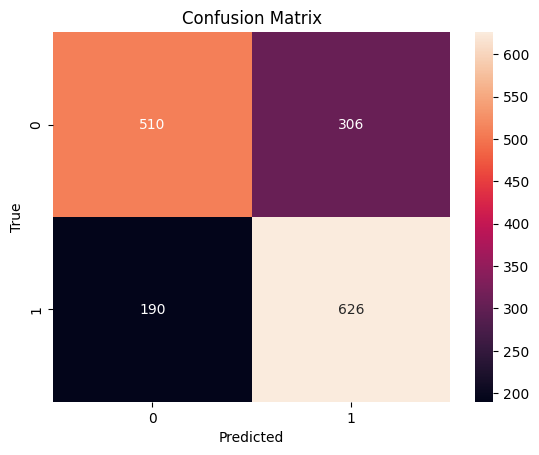

In [47]:
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()